In [1]:
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [2]:
import pandas as pd
import os

folder = "capstone"
files = sorted([f for f in os.listdir(folder) if f.startswith("data_")])

df_list = []

for f in files:
    path = os.path.join(folder, f)
    print("Reading:", f)
    
    chunks = pd.read_csv(path, chunksize=200000)
    
    for chunk in chunks:
        df_list.append(chunk)

df = pd.concat(df_list, ignore_index=True)

df.shape

Reading: data_2025_01.csv
Reading: data_2025_02.csv
Reading: data_2025_03.csv
Reading: data_2025_04.csv
Reading: data_2025_05.csv
Reading: data_2025_06.csv
Reading: data_2025_07.csv
Reading: data_2025_08.csv
Reading: data_2025_09.csv
Reading: data_2025_10.csv
Reading: data_2025_11.csv
Reading: data_2025_12.csv
Reading: data_2026_01.csv
Reading: data_2026_02.csv


(14000000, 21)

In [6]:
df["duration"] = pd.to_numeric(df["duration"], errors="coerce")
df["attention_seconds"] = pd.to_numeric(df["attention_seconds"], errors="coerce")

df["attention_rate"] = df["attention_seconds"] / df["duration"]
df["attention_rate"] = df["attention_rate"].clip(0, 1)

In [ ]:
import statsmodels.formula.api as smf

model = smf.ols(
    formula="""
    attention_rate ~ 
        C(source_type) +
        C(daypart) +
        C(industry) +
        duration +
        age +
        C(gender)
    """,
    data=df
).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:         attention_rate   R-squared:                       0.014
Model:                            OLS   Adj. R-squared:                  0.014
Method:                 Least Squares   F-statistic:                     6550.
Date:                Wed, 01 Apr 2026   Prob (F-statistic):               0.00
Time:                        20:54:30   Log-Likelihood:            -6.7539e+06
No. Observations:            13997555   AIC:                         1.351e+07
Df Residuals:                13997524   BIC:                         1.351e+07
Df Model:                          30                                         
Covariance Type:            nonrobust                                         
                                                     coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------

In [15]:
results_df = model.summary2().tables[1]

results_df

,Coef.,Std.Err.,t,P>|t|,[0.025,0.975]
Intercept,0.157162,0.002351,66.837239,0.000000e+00,0.152553,0.161770
C(source_type)[T.linear],0.069553,0.001299,53.554329,0.000000e+00,0.067007,0.072098
C(daypart)[T.Early Access],0.035371,0.000495,71.466335,0.000000e+00,0.034401,0.036341
C(daypart)[T.Early Fringe],0.023947,0.000317,75.571580,0.000000e+00,0.023326,0.024568
C(daypart)[T.Early Morning],-0.015781,0.000452,-34.951665,1.254705e-267,-0.016666,-0.014896
C(daypart)[T.Late Fringe],0.006376,0.001018,6.264498,3.740393e-10,0.004381,0.008371
C(daypart)[T.Late News],0.051835,0.001229,42.189153,0.000000e+00,0.049427,0.054244
C(daypart)[T.Late Night],-0.009010,0.000612,-14.722488,4.627275e-49,-0.010210,-0.007811
C(daypart)[T.Morning],-0.008948,0.000499,-17.932899,6.540649e-72,-0.009926,-0.007970
C(daypart)[T.Overnight],-0.041245,0.000646,-63.803991,0.000000e+00,-0.042512,-0.039978


In [3]:
def split_industry(ind):
    if pd.isna(ind):
        return []
    return [x.strip().lower() for x in ind.split("/")]

df["industry_tokens"] = df["industry"].apply(split_industry)

In [4]:
import ast

def parse_genres(x):
    if pd.isna(x):
        return []
    try:
        return [str(i).lower() for i in ast.literal_eval(x)]
    except:
        return [str(x).lower()]

df["genre_list"] = df["content_genres"].apply(parse_genres)

In [5]:
def strict_match(ind_tokens, genres):
    if not ind_tokens or not genres:
        return 0
    
    genre_set = set(genres)
    
    for token in ind_tokens:
        if token in genre_set:
            return 1
    
    return 0

df["context_match_strict_v2"] = df.apply(
    lambda x: strict_match(x["industry_tokens"], x["genre_list"]),
    axis=1
)

In [6]:
df["context_match_strict_v2"].value_counts(normalize=True)

context_match_strict_v2
0    0.948189
1    0.051811
Name: proportion, dtype: float64

In [8]:
df["context_match_new"] = df["context_match_strict_v2"]

In [9]:
df["duration"] = pd.to_numeric(df["duration"], errors="coerce")
df["attention_seconds"] = pd.to_numeric(df["attention_seconds"], errors="coerce")

df["attention_rate"] = df["attention_seconds"] / df["duration"]
df["attention_rate"] = df["attention_rate"].clip(0, 1)

In [10]:
df_model_new = df.dropna(subset=[
    "attention_rate",
    "duration",
    "age",
    "source_type",
    "daypart",
    "industry",
    "gender",
    "context_match_new"
]).sample(1500000, random_state=42)

In [11]:
import statsmodels.formula.api as smf

model_new = smf.ols(
    formula="""
    attention_rate ~ 
        context_match_new +
        C(source_type) +
        C(daypart) +
        C(industry) +
        duration +
        age +
        C(gender)
    """,
    data=df_model_new
).fit()

print(model_new.summary())

                            OLS Regression Results                            
Dep. Variable:         attention_rate   R-squared:                       0.014
Model:                            OLS   Adj. R-squared:                  0.014
Method:                 Least Squares   F-statistic:                     681.0
Date:                Sat, 04 Apr 2026   Prob (F-statistic):               0.00
Time:                        22:00:48   Log-Likelihood:            -7.2407e+05
No. Observations:             1500000   AIC:                         1.448e+06
Df Residuals:                 1499968   BIC:                         1.449e+06
Df Model:                          31                                         
Covariance Type:            nonrobust                                         
                                                     coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------

In [22]:
results_new = model_new.summary2().tables[1]
results_new_rounded = results_new.round(3)

results_new_rounded

,Coef.,Std.Err.,t,P>|t|,[0.025,0.975]
Intercept,0.165,0.007,22.917,0.000,0.151,0.179
C(source_type)[T.linear],0.066,0.004,16.620,0.000,0.058,0.074
C(daypart)[T.Early Access],0.036,0.002,23.647,0.000,0.033,0.039
C(daypart)[T.Early Fringe],0.024,0.001,24.816,0.000,0.022,0.026
C(daypart)[T.Early Morning],-0.016,0.001,-11.827,0.000,-0.019,-0.014
C(daypart)[T.Late Fringe],0.009,0.003,3.031,0.002,0.003,0.016
C(daypart)[T.Late News],0.053,0.004,14.148,0.000,0.046,0.061
C(daypart)[T.Late Night],-0.009,0.002,-5.005,0.000,-0.013,-0.006
C(daypart)[T.Morning],-0.010,0.002,-6.241,0.000,-0.013,-0.007
C(daypart)[T.Overnight],-0.043,0.002,-21.670,0.000,-0.047,-0.039


In [12]:
model_industry_new = smf.ols(
    formula="""
    attention_rate ~ 
        context_match_new * C(industry) +
        C(source_type) +
        C(daypart) +
        duration +
        age +
        C(gender)
    """,
    data=df_model_new
).fit()

print(model_industry_new.summary())

                            OLS Regression Results                            
Dep. Variable:         attention_rate   R-squared:                       0.014
Model:                            OLS   Adj. R-squared:                  0.014
Method:                 Least Squares   F-statistic:                     571.3
Date:                Sat, 04 Apr 2026   Prob (F-statistic):               0.00
Time:                        22:01:07   Log-Likelihood:            -7.2405e+05
No. Observations:             1500000   AIC:                         1.448e+06
Df Residuals:                 1499962   BIC:                         1.449e+06
Df Model:                          37                                         
Covariance Type:            nonrobust                                         
                                                                       coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------

In [23]:
results_industry_new = model_industry_new.summary2().tables[1]
results_industry_new_rounded = results_industry_new.round(3)

results_industry_new_rounded

,Coef.,Std.Err.,t,P>|t|,[0.025,0.975]
Intercept,0.165,0.007,22.930,0.000,0.151,0.179
C(industry)[T.Automotive / Vehicles],-0.028,0.006,-4.621,0.000,-0.039,-0.016
C(industry)[T.Consumer Products],-0.025,0.006,-4.125,0.000,-0.036,-0.013
C(industry)[T.Cosmetic / Hygiene],-0.023,0.006,-3.788,0.000,-0.035,-0.011
C(industry)[T.Education],-0.033,0.007,-4.481,0.000,-0.048,-0.019
C(industry)[T.Electronics / Technology],-0.017,0.006,-2.584,0.010,-0.029,-0.004
C(industry)[T.Entertainment / Media / Leisure],-0.011,0.006,-1.836,0.066,-0.022,0.001
C(industry)[T.Food / Beverages],-0.019,0.006,-3.132,0.002,-0.030,-0.007
C(industry)[T.Government / Organizations],-0.019,0.006,-3.166,0.002,-0.032,-0.007
C(industry)[T.Health],-0.025,0.006,-4.217,0.000,-0.036,-0.013


In [13]:
results_industry_new = model_industry_new.summary2().tables[1]

interaction_new = results_industry_new.loc[
    results_industry_new.index.str.contains("context_match_new:C")
].copy()

interaction_new.round(3)

,Coef.,Std.Err.,t,P>|t|,[0.025,0.975]
context_match_new:C(industry)[T.Automotive / Vehicles],0.000,0.000,1.588,0.112,-0.000,0.000
context_match_new:C(industry)[T.Consumer Products],0.000,0.000,0.245,0.807,-0.000,0.000
context_match_new:C(industry)[T.Cosmetic / Hygiene],-0.000,0.000,-1.840,0.066,-0.000,0.000
context_match_new:C(industry)[T.Education],-0.000,0.000,-1.751,0.080,-0.000,0.000
context_match_new:C(industry)[T.Electronics / Technology],0.018,0.046,0.396,0.692,-0.071,0.108
context_match_new:C(industry)[T.Entertainment / Media / Leisure],-0.006,0.008,-0.752,0.452,-0.022,0.010
context_match_new:C(industry)[T.Food / Beverages],-0.031,0.009,-3.260,0.001,-0.049,-0.012
context_match_new:C(industry)[T.Government / Organizations],0.047,0.025,1.870,0.062,-0.002,0.097
context_match_new:C(industry)[T.Health],-0.021,0.011,-1.925,0.054,-0.042,0.000
context_match_new:C(industry)[T.Home and Garden],0.000,0.000,NaN,NaN,0.000,0.000


In [14]:
industry_lift_new = df_model_new.groupby(
    ["industry", "context_match_new"]
)["attention_rate"].mean().unstack()

industry_lift_new["lift"] = industry_lift_new[1] - industry_lift_new[0]

industry_lift_new = industry_lift_new.round(3)

industry_lift_new.sort_values("lift", ascending=False)

context_match_new,0,1,lift
industry,,,
Government / Organizations,0.342,0.392,0.050
Electronics / Technology,0.350,0.387,0.037
Legal / Financial,0.346,0.372,0.026
Entertainment / Media / Leisure,0.364,0.385,0.021
Travel,0.359,0.374,0.016
Health,0.340,0.324,-0.016
Food / Beverages,0.357,0.340,-0.017
Apparel / Footwear / Accessories,0.374,NaN,NaN
Automotive / Vehicles,0.345,NaN,NaN


In [15]:
daypart_lift_new = df_model_new.groupby(
    ["daypart", "context_match_new"]
)["attention_rate"].mean().unstack()

daypart_lift_new["lift"] = daypart_lift_new[1] - daypart_lift_new[0]

daypart_lift_new = daypart_lift_new.round(3)

daypart_lift_new.sort_values("lift", ascending=False)

context_match_new,0,1,lift
daypart,,,
Late Night,0.322,0.380,0.058
Early Morning,0.324,0.367,0.043
Prime Access,0.381,0.415,0.033
Early Access,0.375,0.402,0.027
Prime,0.377,0.398,0.021
Early Fringe,0.358,0.377,0.020
Daytime,0.336,0.341,0.005
Late Fringe,0.343,0.346,0.003
Late News,0.388,0.389,0.000


In [24]:
pivot_new = df_model_new.groupby(
    ["industry", "daypart", "context_match_new"]
)["attention_rate"].mean().unstack()

pivot_new["lift"] = pivot_new[1] - pivot_new[0]

heatmap_data_new = pivot_new["lift"].unstack()

mkdir -p failed for path /home/jovyan/.cache/matplotlib: [Errno 13] Permission denied: '/home/jovyan/.cache/matplotlib'
Matplotlib created a temporary cache directory at /tmp/matplotlib-vawhw794 because there was an issue with the default path (/home/jovyan/.cache/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


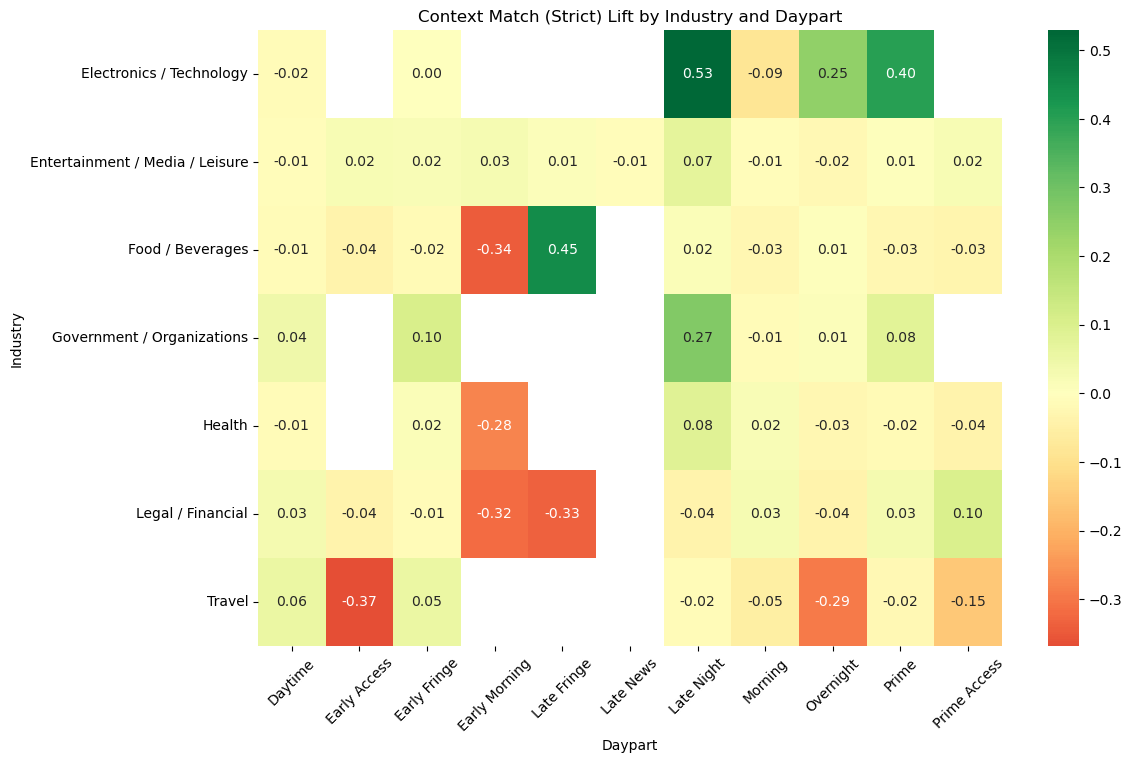

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

heatmap_data_plot = heatmap_data_new.dropna(how="all")

plt.figure(figsize=(12, 8))

sns.heatmap(
    heatmap_data_plot,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    center=0
)

plt.title("Context Match (Strict) Lift by Industry and Daypart")
plt.xlabel("Daypart")
plt.ylabel("Industry")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()

In [11]:
model_channel = smf.ols(
    formula="""
    attention_rate ~ 
        context_match_new * C(source_type) +
        C(daypart) +
        C(industry) +
        duration +
        age +
        C(gender)
    """,
    data=df_model_new
).fit()

print(model_channel.summary())

                            OLS Regression Results                            
Dep. Variable:         attention_rate   R-squared:                       0.014
Model:                            OLS   Adj. R-squared:                  0.014
Method:                 Least Squares   F-statistic:                     659.8
Date:                Sun, 05 Apr 2026   Prob (F-statistic):               0.00
Time:                        02:55:44   Log-Likelihood:            -7.2407e+05
No. Observations:             1500000   AIC:                         1.448e+06
Df Residuals:                 1499967   BIC:                         1.449e+06
Df Model:                          32                                         
Covariance Type:            nonrobust                                         
                                                     coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------

In [12]:
model_channel = model_channel.summary2().tables[1]
model_channel = model_channel.round(3)

model_channel

,Coef.,Std.Err.,t,P>|t|,[0.025,0.975]
Intercept,0.165,0.007,22.901,0.000,0.151,0.179
C(source_type)[T.linear],0.066,0.004,16.601,0.000,0.058,0.074
C(daypart)[T.Early Access],0.036,0.002,23.646,0.000,0.033,0.039
C(daypart)[T.Early Fringe],0.024,0.001,24.816,0.000,0.022,0.026
C(daypart)[T.Early Morning],-0.016,0.001,-11.827,0.000,-0.019,-0.014
C(daypart)[T.Late Fringe],0.009,0.003,3.031,0.002,0.003,0.016
C(daypart)[T.Late News],0.053,0.004,14.148,0.000,0.046,0.061
C(daypart)[T.Late Night],-0.009,0.002,-5.005,0.000,-0.013,-0.006
C(daypart)[T.Morning],-0.010,0.002,-6.241,0.000,-0.013,-0.007
C(daypart)[T.Overnight],-0.043,0.002,-21.669,0.000,-0.047,-0.039
